# 02 — Inspección de muones desde el binario DAT

Lee el archivo `DAT001001` (output binario de CORSIKA), filtra muones (`particle_id ∈ {5, 6}`) y muestra:

1. Resumen del run + conteo de eventos y muones.
2. Espectro de energía (log-log).
3. Distribución de ángulo cenital θ.
4. Distribución azimutal φ.
5. Mapa 2D θ–φ.
6. Posición de impacto (x, y) en el OBSLEV.

**Pre-requisitos** (una vez, en tu env conda):
```bash
pip install corsikaio pandas matplotlib numpy
```

**Nota:** si `primary_id = 1` (gamma) en el `.lst`, este notebook va a mostrar **0 muones**. Es la firma del bug viejo de PRMPAR. Rerunear con `PRMPAR 14` antes de interpretar.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.corsika import CorsikaRun, PARTICLE_NAMES

In [2]:
run = CorsikaRun(REPO_ROOT / "sim" / "output", run_number=1001)
md = run.lst.metadata()
print(f"RUNNR={md.run_number}, primario={md.primary_name} (id={md.primary_id}), "
      f"E ∈ [{md.energy_min_gev:.0f}, {md.energy_max_gev:.0e}] GeV, "
      f"θ ∈ [{md.theta_min_deg}, {md.theta_max_deg}]°, "
      f"OBSLEV={md.obslev_cm/1e5:.2f} km")

RUNNR=1001, primario=p (id=14), E ∈ [10, 1e+05] GeV, θ ∈ [0.0, 89.0]°, OBSLEV=2.00 km


## Carga del binario

In [3]:
muons = run.particles.muons()
print(f"Total muones (μ⁺ + μ⁻): {len(muons)}")
if not muons.empty:
    n_events = muons['event'].nunique()
    print(f"Eventos con ≥1 muon: {n_events}/{md.n_showers} ({n_events/md.n_showers:.1%})")
    print(f"Energías: {muons['energy_gev'].describe()[['min','50%','mean','max']].to_dict()}")
    muons.head()

/home/erick/anaconda3/envs/muon-tomography/lib/python3.11/site-packages/corsikaio/file.py:89: UnknownNewCORSIKA: CORSIKA version 7.804999828338623 is newer than the newest supported version.Block data types might miss fields introduced after version 7.801000118255615.
  warnings.warn(msg, category=UnknownNewCORSIKA)


Total muones (μ⁺ + μ⁻): 109
Eventos con ≥1 muon: 67/500 (13.4%)
Energías: {'min': 0.31600947926273293, '50%': 1.7064341236113196, 'mean': 3.2904586667891547, 'max': 24.885160723995902}


In [4]:
# Si no hay muones, parar aca con un mensaje claro.
if muons.empty:
    raise RuntimeError(
        f"0 muones en DAT001001. Primario actual: {md.primary_name}.\n"
        "Posibles causas: PRMPAR != 14 (proton), o el run aun no fue regenerado "
        "tras corregir el bug. Ver notebooks/01 para diagnostico."
    )

## 1. Espectro de energía

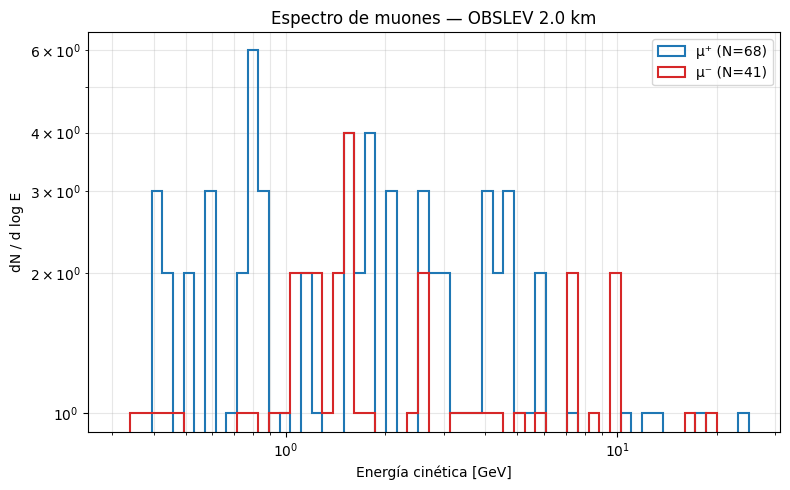

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

bins = np.logspace(np.log10(max(muons['energy_gev'].min(), 1e-3)),
                    np.log10(muons['energy_gev'].max()), 60)
for pid, label, color in [(5, "μ⁺", "tab:blue"), (6, "μ⁻", "tab:red")]:
    e = muons.loc[muons['particle_id'] == pid, 'energy_gev']
    if len(e):
        ax.hist(e, bins=bins, histtype='step', lw=1.5, label=f"{label} (N={len(e)})", color=color)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Energía cinética [GeV]')
ax.set_ylabel('dN / d log E')
ax.set_title(f'Espectro de muones — OBSLEV {md.obslev_cm/1e5:.1f} km')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

**Lectura esperada:** espectro decreciente, pico ~GeV para muones que sobreviven hasta el OBSLEV. La razón μ⁺/μ⁻ debe estar cerca de 1.27 (asimetría conocida por la composición del flujo cósmico: protones primarios → más π⁺ → más μ⁺).

## 2. Ángulo cenital θ

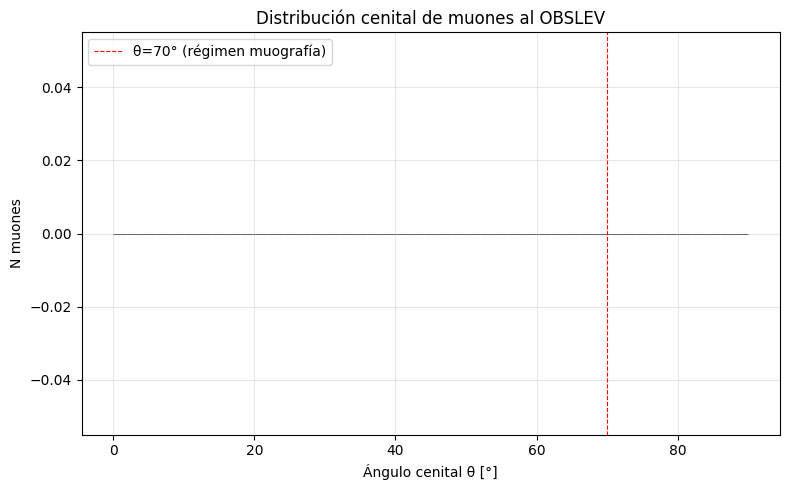

Muones con θ > 70°: 109 (100.0%) — útiles para muografía horizontal


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

theta_deg = np.degrees(muons['theta_rad'])
ax.hist(theta_deg, bins=np.linspace(0, 90, 46), color='tab:gray', edgecolor='k', lw=0.5)
ax.set_xlabel('Ángulo cenital θ [°]')
ax.set_ylabel('N muones')
ax.set_title('Distribución cenital de muones al OBSLEV')
ax.grid(alpha=0.3)
ax.axvline(70, color='red', ls='--', lw=0.8, label='θ=70° (régimen muografía)')
ax.legend()
plt.tight_layout()
plt.show()

n_horiz = (theta_deg > 70).sum()
print(f"Muones con θ > 70°: {n_horiz} ({n_horiz/len(muons):.1%}) — útiles para muografía horizontal")

**Lectura esperada:** distribución pico cerca de θ≈0–30° (muones casi verticales son los más abundantes), cola larga hacia 90°. Para muografía importan los muones casi horizontales (θ > 70°) — atraviesan el edificio volcánico desde un lado.

## 3. Ángulo azimutal φ

ValueError: 'tab:teal' is not a valid color value.

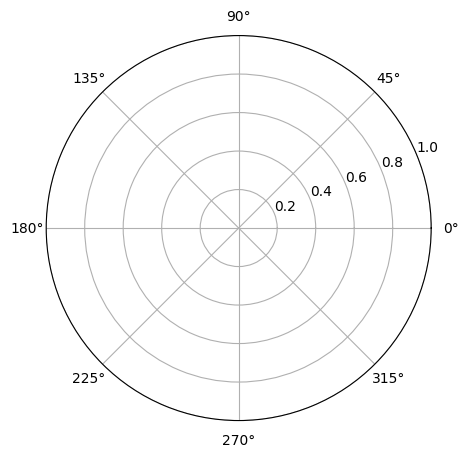

In [7]:
fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={'projection': 'polar'})

phi = muons['phi_rad'].to_numpy()
ax.hist(phi, bins=np.linspace(-np.pi, np.pi, 49), color='tab:teal')
ax.set_title('Distribución azimutal φ')
ax.set_theta_zero_location('E')
ax.set_theta_direction(1)
plt.tight_layout()
plt.show()

**Lectura esperada:** uniforme (estamos simulando PHIP 0–360° isotrópico). Cualquier asimetría es ruido estadístico (500 showers es poco) o efecto del campo geomagnético.

## 4. Mapa 2D θ–φ

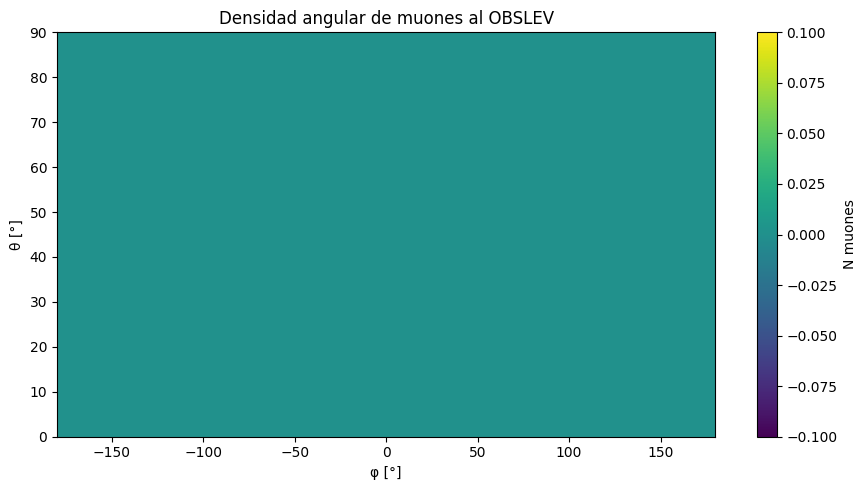

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

h, xe, ye, im = ax.hist2d(
    np.degrees(muons['phi_rad']),
    np.degrees(muons['theta_rad']),
    bins=[36, 30],
    range=[[-180, 180], [0, 90]],
    cmap='viridis',
)
ax.set_xlabel('φ [°]')
ax.set_ylabel('θ [°]')
ax.set_title('Densidad angular de muones al OBSLEV')
plt.colorbar(im, ax=ax, label='N muones')
plt.tight_layout()
plt.show()

## 5. Posición de impacto (x, y)

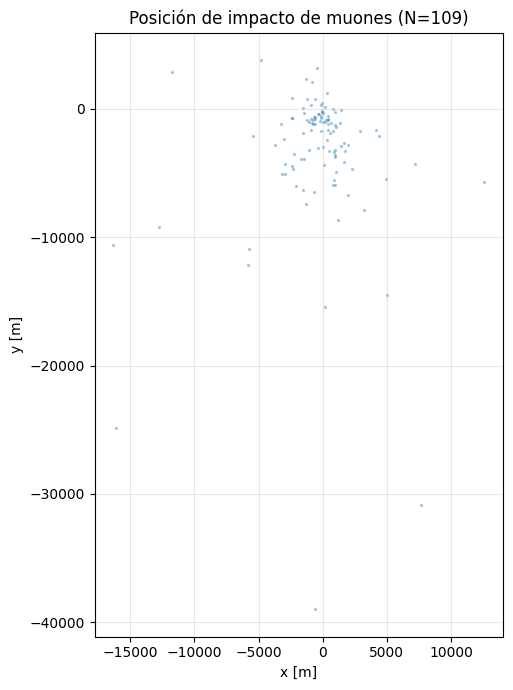

Radio mediano: 3086.6 m, máximo: 38989.0 m


In [9]:
fig, ax = plt.subplots(figsize=(7, 7))

x_m = muons['x_cm'].to_numpy() / 100
y_m = muons['y_cm'].to_numpy() / 100
ax.scatter(x_m, y_m, s=2, alpha=0.3, color='tab:blue')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_title(f'Posición de impacto de muones (N={len(muons)})')
ax.set_aspect('equal')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

r_m = np.sqrt(x_m**2 + y_m**2)
print(f'Radio mediano: {np.median(r_m):.1f} m, máximo: {r_m.max():.1f} m')

**Lectura esperada:** densidad pico cerca de (0, 0) — eje del primer primario — con cola lateral que crece con θ y E del primario.

---

## Próximos pasos sugeridos

- **Mezcla de primarios:** correr p (90%) + He (9%) y combinarlos con pesos del espectro de Gaisser.
- **Cortes geométricos:** seleccionar muones con θ y φ apuntando al volcán (requiere DEM + posición del observador).
- **Flujo absoluto:** convertir a flujo (muones / m² / s / sr) usando el espectro asumido y el tiempo de exposición.
- **Output Parquet:** persistir el DataFrame de muones (`muons.to_parquet(...)`) — mucho más rápido de releer que el binario.